In [4]:
# Mount drive

from google.colab import drive
drive.mount('/content/drive')
import os, json

BASE_DIR = '/content/drive/MyDrive/multilingual_health_qa'
DATA_DIR = f'{BASE_DIR}/data'
PLOT_DIR = f'{BASE_DIR}/plots'
OUT_DIR  = f'{BASE_DIR}/outputs'
os.makedirs(PLOT_DIR, exist_ok=True)
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


In [5]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
print("Imports ready.")

Imports ready.


In [ ]:
# CELL 2 — Build results table directly from the log (no hardcoded scores)

LOG_PATH = f'{DATA_DIR}/experiment_log.json'
with open(LOG_PATH, 'r') as f:
    log = json.load(f)

# (key in log, Exp label, friendly name, model, lora_r, prompt, trained, key change)
exp_order = [
    ("exp01_mt5small_zeroshot",    "Exp 1", "mt5-small\nZero-Shot",     "google/mt5-small",     None, "v1", False, "Baseline: no fine-tuning"),
    ("exp02_mt5small_lora_r16",    "Exp 2", "mt5-small\nLoRA r=16",     "google/mt5-small",     16,   "v1", True,  "Added LoRA fine-tuning to Exp 1 model"),
    ("exp03_flanT5base_lora_r16",  "Exp 3", "flan-t5-base\nLoRA r=16",  "google/flan-t5-base",  16,   "v1", True,  "Switched to instruction-tuned backbone"),
    ("exp04_flanT5base_lora_r32",  "Exp 4", "flan-t5-base\nLoRA r=32",  "google/flan-t5-base",  32,   "v1", True,  "Doubled LoRA rank: r=16 → r=32"),
    ("exp05_flanT5base_promptv2",  "Exp 5", "flan-t5-base\nPrompt v2",  "google/flan-t5-base",  16,   "v2", True,  "Added health-assistant role to prompt"),
    ("exp06_flanT5large_lora_r16", "Exp 6", "flan-t5-large\nLoRA r=16", "google/flan-t5-large", 16,   "v1", True,  "Scaled backbone: base → large"),
]

rows = []
for key, exp_id, name, model_name, lora_r, prompt, trained, change in exp_order:
    entry = log.get(key, {})
    m = entry.get('metrics', {})
    rows.append({
        "Exp": exp_id, "Name": name, "Model": model_name, "LoRA_r": lora_r,
        "Prompt": prompt, "Trained": trained,
        "Val_R1": m.get('val_rouge1'), "Val_RL": m.get('val_rougeL'),
        "Zindi": pd.to_numeric(m.get('zindi_score'), errors='coerce'),
        "Change": change, "_in_log": key in log
    })

results = pd.DataFrame(rows)

missing = results.loc[~results['_in_log'], 'Exp'].tolist()
if missing:
    print(f"  Not yet in experiment_log.json: {missing} — run the backfill fix first.\n")

results = results.drop(columns=['_in_log'])
print("=== RESULTS TABLE ===")
print(results[['Exp','Name','Model','LoRA_r','Prompt','Val_R1','Val_RL','Zindi','Change']].to_string(index=False))

=== RESULTS TABLE ===
  Exp                     Name                Model  LoRA_r Prompt  Val_R1  Val_RL    Zindi                                 Change
Exp 1     mt5-small\nZero-Shot     google/mt5-small     NaN     v1  0.0013  0.0013 0.001670               Baseline: no fine-tuning
Exp 2     mt5-small\nLoRA r=16     google/mt5-small    16.0     v1  0.0034  0.0033 0.004928  Added LoRA fine-tuning to Exp 1 model
Exp 3  flan-t5-base\nLoRA r=16  google/flan-t5-base    16.0     v1  0.1056  0.0910 0.155076 Switched to instruction-tuned backbone
Exp 4  flan-t5-base\nLoRA r=32  google/flan-t5-base    32.0     v1  0.1057  0.0910 0.152634         Doubled LoRA rank: r=16 → r=32
Exp 5  flan-t5-base\nPrompt v2  google/flan-t5-base    16.0     v2  0.0773  0.0690 0.141087  Added health-assistant role to prompt
Exp 6 flan-t5-large\nLoRA r=16 google/flan-t5-large    16.0     v1  0.0777  0.0696 0.149083          Scaled backbone: base → large


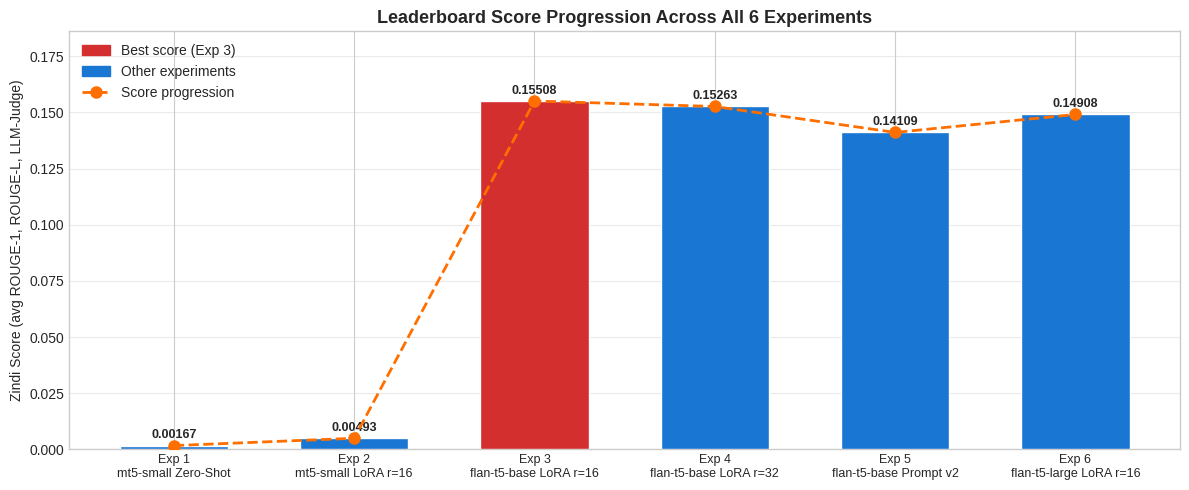

Saved: /content/drive/MyDrive/multilingual_health_qa/plots/leaderboard_progression.png


In [ ]:
# CELL 3 — Leaderboard progression plot

fig, ax = plt.subplots(figsize=(12, 5))

x      = range(len(results))
scores = results['Zindi'].values
labels = [r.replace('\n', ' ') for r in results['Name'].values]
colors = ['#d32f2f' if s == np.nanmax(scores) else '#1976D2' for s in scores]

bars = ax.bar(x, scores, color=colors, edgecolor='white', width=0.6, zorder=3)
ax.plot(x, scores, 'o--', color='#FF6F00', linewidth=2, markersize=8, zorder=4,
        label='Score progression')

for bar, score in zip(bars, scores):
    if not np.isnan(score):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{score:.5f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

best_idx = int(np.nanargmax(scores))
best_patch  = mpatches.Patch(color='#d32f2f', label=f'Best score ({results.iloc[best_idx]["Exp"]})')
other_patch = mpatches.Patch(color='#1976D2', label='Other experiments')
ax.legend(handles=[best_patch, other_patch, ax.get_lines()[0]], fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([f"{results.iloc[i]['Exp']}\n{l}" for i, l in enumerate(labels)], fontsize=9)
ax.set_ylabel('Zindi Score (avg ROUGE-1, ROUGE-L, LLM-Judge)')
ax.set_title('Leaderboard Score Progression Across All 6 Experiments', fontsize=13, fontweight='bold')
ax.set_ylim(0, np.nanmax(scores) * 1.2)
ax.grid(axis='y', alpha=0.4, zorder=0)

plt.tight_layout()
path = f'{PLOT_DIR}/leaderboard_progression.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

In [ ]:
# CELL 4 — Clean comparison table for the report

display_cols = ['Exp', 'Model', 'LoRA_r', 'Prompt', 'Val_R1', 'Val_RL', 'Zindi', 'Change']
display = results[display_cols].copy()
display['LoRA_r'] = display['LoRA_r'].fillna('None').astype(str)
display['Zindi']  = display['Zindi'].map(lambda x: f'{x:.6f}' if pd.notna(x) else 'N/A')
display.columns   = ['Experiment', 'Model', 'LoRA Rank', 'Prompt', 'Val ROUGE-1', 'Val ROUGE-L', 'Zindi Score', 'Key Change']

print("=== EXPERIMENT COMPARISON TABLE (copy into report) ===")
print(display.to_string(index=False))

csv_path = f'{DATA_DIR}/experiment_summary.csv'
display.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

=== EXPERIMENT COMPARISON TABLE (copy into report) ===
Experiment                Model LoRA Rank Prompt  Val ROUGE-1  Val ROUGE-L Zindi Score                             Key Change
     Exp 1     google/mt5-small      None     v1       0.0013       0.0013    0.001670               Baseline: no fine-tuning
     Exp 2     google/mt5-small      16.0     v1       0.0034       0.0033    0.004928  Added LoRA fine-tuning to Exp 1 model
     Exp 3  google/flan-t5-base      16.0     v1       0.1056       0.0910    0.155076 Switched to instruction-tuned backbone
     Exp 4  google/flan-t5-base      32.0     v1       0.1057       0.0910    0.152634         Doubled LoRA rank: r=16 → r=32
     Exp 5  google/flan-t5-base      16.0     v2       0.0773       0.0690    0.141087  Added health-assistant role to prompt
     Exp 6 google/flan-t5-large      16.0     v1       0.0777       0.0696    0.149083          Scaled backbone: base → large

Saved: /content/drive/MyDrive/multilingual_health_qa/data/expe

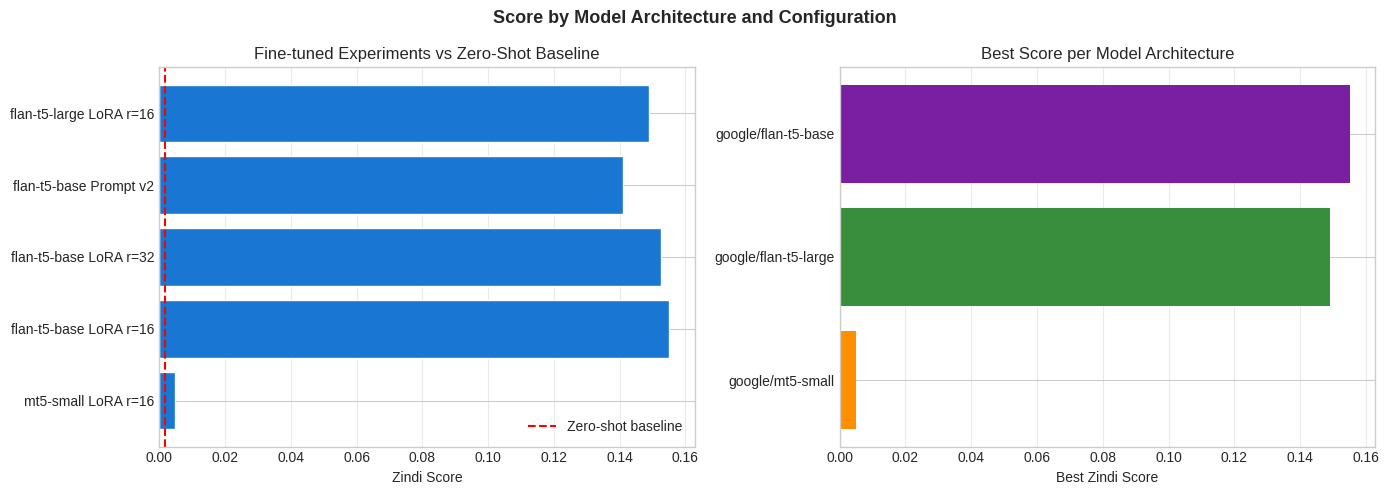

Saved: /content/drive/MyDrive/multilingual_health_qa/plots/model_comparison.png


In [ ]:
# CELL 5 — Model architecture comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Score by Model Architecture and Configuration', fontsize=13, fontweight='bold')

trained = results[results['Trained'] == True]
axes[0].barh(trained['Name'].str.replace('\n', ' '), trained['Zindi'], color='#1976D2', edgecolor='white')
baseline_score = results.loc[results['Trained']==False, 'Zindi'].values
if len(baseline_score) and not np.isnan(baseline_score[0]):
    axes[0].axvline(baseline_score[0], color='red', linestyle='--', label='Zero-shot baseline')
    axes[0].legend()
axes[0].set_xlabel('Zindi Score')
axes[0].set_title('Fine-tuned Experiments vs Zero-Shot Baseline')
axes[0].grid(axis='x', alpha=0.4)

model_groups = results.groupby('Model')['Zindi'].max().sort_values()
axes[1].barh(model_groups.index, model_groups.values, color=['#FF8F00', '#388E3C', '#7B1FA2'])
axes[1].set_xlabel('Best Zindi Score')
axes[1].set_title('Best Score per Model Architecture')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
path = f'{PLOT_DIR}/model_comparison.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

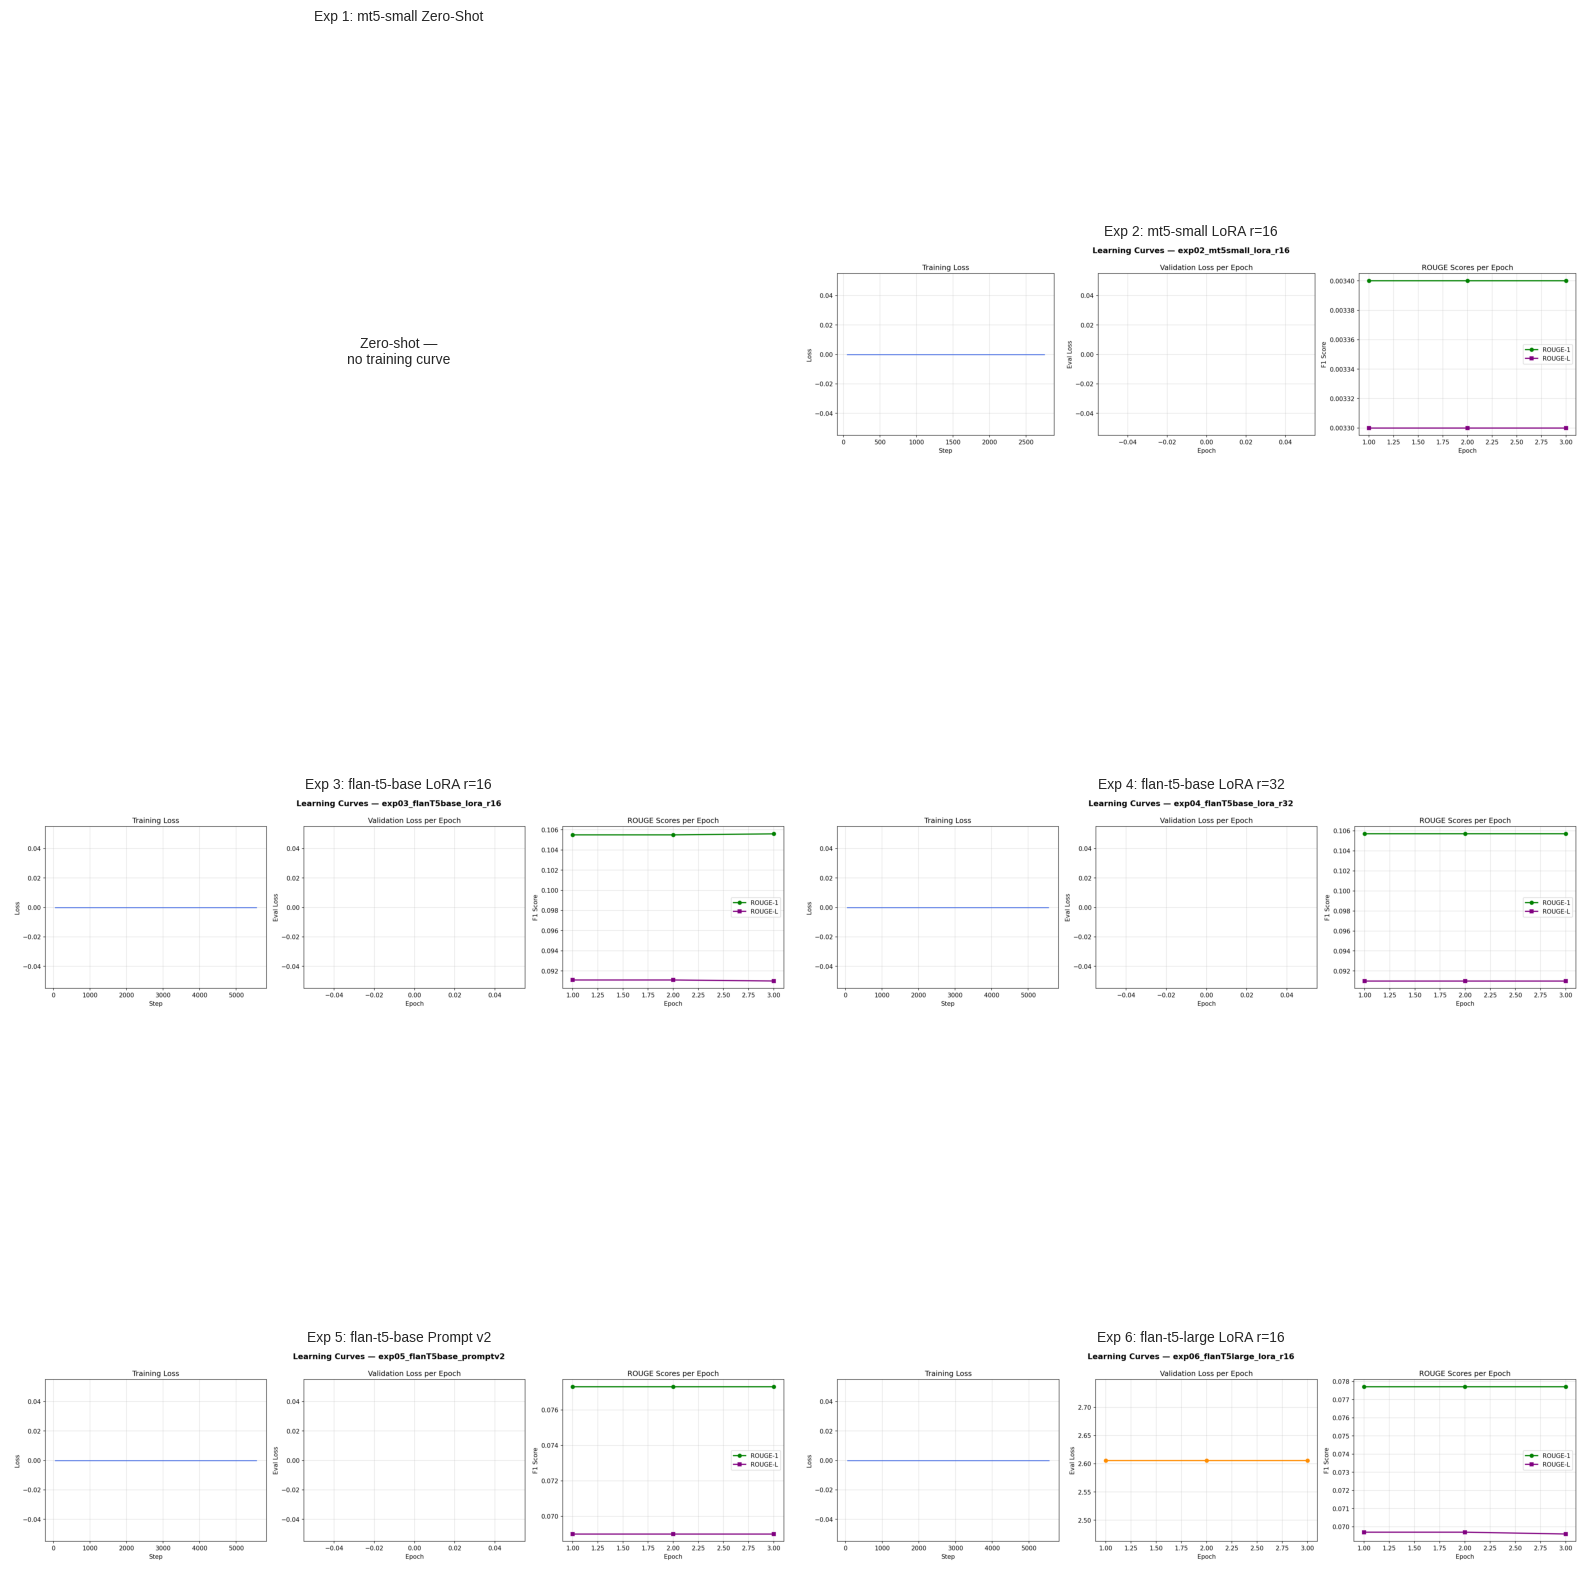

Saved: /content/drive/MyDrive/multilingual_health_qa/plots/all_learning_curves_gallery.png


In [ ]:
# CELL 6 — Learning curves gallery

exp_keys = [e[0] for e in exp_order]
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, (key, exp_label, name, *_rest) in zip(axes, exp_order):
    img_path = f'{PLOT_DIR}/learning_curves_{key}.png'
    if os.path.exists(img_path):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f"{exp_label}: {name.replace(chr(10),' ')}", fontsize=10)
    else:
        ax.text(0.5, 0.5, "Zero-shot —\nno training curve" if key == "exp01_mt5small_zeroshot"
                 else f"Missing:\n{key}", ha='center', va='center', fontsize=10)
        ax.set_title(f"{exp_label}: {name.replace(chr(10),' ')}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
gallery_path = f'{PLOT_DIR}/all_learning_curves_gallery.png'
plt.savefig(gallery_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {gallery_path}")

In [ ]:
# run only once then restart runtime

!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=2391a238ca9e803be37b08eaf6d7d1b6374e9c0bcc434b5006b5888d366321a3
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Generating predictions on validation set (a few minutes)...
Language    N   ROUGE1   ROUGEL
 Aka_Gha 1114 0.030878 0.024397
 Amh_Eth  462 0.000000 0.000000
 Eng_Eth  564 0.181247 0.141444
 Eng_Gha 1104 0.250191 0.213807
 Eng_Ken  390 0.120488 0.098306
 Eng_Uga 1688 0.106003 0.086484
 Lug_Uga  846 0.031992 0.029675
 Swa_Ken  518 0.025566 0.023702


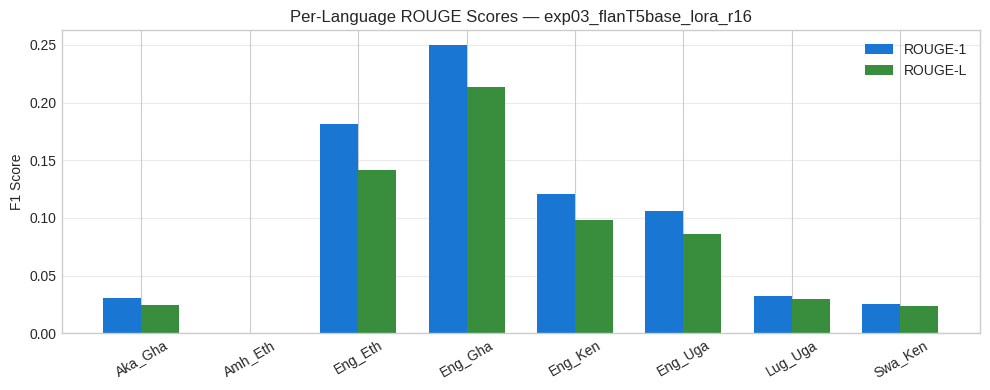

Saved: /content/drive/MyDrive/multilingual_health_qa/plots/per_language_rouge.png


In [ ]:
# CELL 7 — Real per-language ROUGE on validation set

!pip install evaluate
!pip install rouge_score
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel
import evaluate as hf_evaluate

rouge_metric = hf_evaluate.load("rouge")

BEST_EXP        = "exp03_flanT5base_lora_r16"
BEST_BASE_MODEL = "google/flan-t5-base"
model_path = f'{OUT_DIR}/model_{BEST_EXP}'

tokenizer  = AutoTokenizer.from_pretrained(model_path)
base_model = AutoModelForSeq2SeqLM.from_pretrained(BEST_BASE_MODEL)
model      = PeftModel.from_pretrained(base_model, model_path)
model.eval()
if torch.cuda.is_available():
    model = model.cuda()

val = pd.read_csv(f'{DATA_DIR}/val_clean.csv')

def generate_batch(texts, batch_size=16, max_input=128, max_target=64, num_beams=4):
    answers = []
    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt', max_length=max_input,
                            truncation=True, padding=True)
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_target, num_beams=num_beams)
        answers.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
    return answers

print("Generating predictions on validation set (a few minutes)...")
val['predicted'] = generate_batch(val['input_text'].tolist())

rows = []
for lang in sorted(val['subset'].unique()):
    sub = val[val['subset'] == lang]
    r = rouge_metric.compute(
        predictions=[p.strip() for p in sub['predicted']],
        references=[str(t).strip() for t in sub['target_text']],
        use_stemmer=True
    )
    rows.append({'Language': lang, 'N': len(sub), 'ROUGE1': r['rouge1'], 'ROUGEL': r['rougeL']})

lang_scores = pd.DataFrame(rows)
print(lang_scores.to_string(index=False))
lang_scores.to_csv(f'{DATA_DIR}/per_language_rouge_{BEST_EXP}.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 4))
x, width = range(len(lang_scores)), 0.35
ax.bar([i - width/2 for i in x], lang_scores['ROUGE1'], width, label='ROUGE-1', color='#1976D2')
ax.bar([i + width/2 for i in x], lang_scores['ROUGEL'], width, label='ROUGE-L', color='#388E3C')
ax.set_xticks(x)
ax.set_xticklabels(lang_scores['Language'], rotation=30)
ax.set_ylabel('F1 Score')
ax.set_title(f'Per-Language ROUGE Scores — {BEST_EXP}')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
path = f'{PLOT_DIR}/per_language_rouge.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

In [ ]:
# CELL 8 — Summary printout

best     = results.loc[results['Zindi'].idxmax()]
baseline = results.loc[0, 'Zindi']

print("=" * 60)
print("PROJECT RESULTS SUMMARY — COPY INTO REPORT")
print("=" * 60)
print(f"Total experiments run : {len(results)}")
print(f"Baseline Zindi score  : {baseline:.5f}  (Exp 1 — zero-shot)")
print(f"Best Zindi score      : {best['Zindi']:.5f}  ({best['Exp']} — {best['Name'].replace(chr(10),' ')})")
print(f"Improvement           : +{best['Zindi']-baseline:.5f}")
print(f"Best model            : {best['Model']}")
print(f"Best LoRA rank        : {best['LoRA_r']}")
print(f"Best prompt version   : {best['Prompt']}")
print("\nScore progression:")
for _, row in results.iterrows():
    marker = "  BEST" if row['Zindi'] == results['Zindi'].max() else ""
    print(f"  {row['Exp']}: {row['Zindi']:.6f}{marker}")
print(f"\nPlots saved to: {PLOT_DIR}")

PROJECT RESULTS SUMMARY — COPY INTO REPORT
Total experiments run : 6
Baseline Zindi score  : 0.00167  (Exp 1 — zero-shot)
Best Zindi score      : 0.15508  (Exp 3 — flan-t5-base LoRA r=16)
Improvement           : +0.15341
Best model            : google/flan-t5-base
Best LoRA rank        : 16.0
Best prompt version   : v1

Score progression:
  Exp 1: 0.001670
  Exp 2: 0.004928
  Exp 3: 0.155076  BEST
  Exp 4: 0.152634
  Exp 5: 0.141087
  Exp 6: 0.149083

Plots saved to: /content/drive/MyDrive/multilingual_health_qa/plots


In [ ]:
!pip install nbformat

In [2]:

# Disable widget metadata saving
from tqdm import tqdm
import os
os.environ["TQDM_DISABLE"] = "0"

# Tell Jupyter not to save widget state
%config Application.log_level = 'WARN'

In [6]:
import json
notebook_path = "/content/drive/MyDrive/Colab Notebooks/04_results_summary.ipynb"
with open(notebook_path, "r") as f:
    nb = json.load(f)
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]
with open(notebook_path, "w") as f:
    json.dump(nb, f, indent=1)
print(" Fixed")

 Fixed
